# Search-17 — Sélection empirique d'algorithmes : 6 paradigmes sur Sudoku

**Série** : Search / Part1-Foundations (17/16 — sélection empirique)

**Durée estimée** : ~1h30 (lecture + exécution)

**Prérequis** : notions de recherche heuristique et métaheuristique (cf. `Search-11`, `Search-11b`), compréhension du problème Sudoku (9x9, 81 cases, 4 contraintes : ligne/colonne/bloc/somme implicite). Familiarité avec CP-SAT et Z3 conseillée.

**Kernel** : `python3` (OR-Tools + z3-solver + pandas + matplotlib)

---

## Objectifs

- Comprendre le **problème de sélection d'algorithmes** (Rice 1976) : étant donné un problème, comment choisir le paradigme de résolution le mieux adapté ?
- Découvrir empiriquement le **principe "No Free Lunch"** (Wolpert 1996) : aucun algorithme ne domine tous les autres sur toutes les instances.
- Comparer **6 paradigmes** de résolution de Sudoku sur 30 instances (3 niveaux de difficulté) :
  1. Backtracking naïf
  2. Backtracking + heuristique MRV
  3. Dancing Links (Algorithm X de Knuth)
  4. Algorithme génétique
  5. Recuit simulé
  6. Programmation par contraintes (CP-SAT, OR-Tools)
  7. SMT (Z3)
- Visualiser le **front de Pareto** (temps vs. qualité) et identifier le **gagnant selon le budget temps** ou la **difficulté de l'instance**.

---

## Navigation

| Précédent | Suivant |
|-----------|---------|
| [Search-16-QuikGraph](Search-16-QuikGraph.ipynb) | *fin de partie Part1-Foundations* (transition vers Part2 : `Search-9-Heuristics`) |

---

## Sources et attributions

Ce notebook est une **distillation pédagogique** d'un projet de L4 EPITA SCIA 2026 (Intelligence Symbolique), auteur **Théodore Deguest**, dépôt [`L4-Benchmark-Cross-Paradigm`](https://github.com/jsboigeEpita/L4-Benchmark-Cross-Paradigm), licence **MIT**. Les 6 solveurs Sudoku et leur harnais de benchmark sont reproduits verbatim depuis la PR source du projet étudiant (PR #42, dépôt privé EPITA — convention de distillation : citer l'auteur, lier la PR, expliciter le périmètre).

> **Note sur la distillation** : ce notebook ne reproduit que la **tranche 1/3** (Sudoku). Les tranches **Puissance 4** (minimax/alpha-beta/MCTS) et **Wordle** (élimination bayésienne/entropie/CSP) sont en chantier dans le projet étudiant et seront distillées dans des notebooks ultérieurs. Citer le projet pour le périmètre complet.


## 1. Pourquoi la sélection d'algorithmes est-elle un problème difficile ?

### 1.1 Le théorème "No Free Lunch" (Wolpert 1996)

En 1996, David Wolpert démontre un résultat contre-intuitif : **moyennée sur tous les problèmes possibles, toute paire d'algorithmes a la même performance moyenne**. Ce qui signifie qu'aucun algorithme n'est *universellement* meilleur qu'un autre — un algorithme excellent sur une classe de problèmes sera médiocre sur une autre.

**Conséquence pratique** : pour un problème *donné* (ici, Sudoku 9x9), la question pertinente n'est pas "quel est le meilleur algorithme en général ?" mais "quel algorithme performe le mieux sur **mon** problème, avec **mon** budget, sur **mes** instances ?".

C'est précisément l'objet du **sélection empirique d'algorithmes** (Empirical Algorithm Selection) : comparer expérimentalement plusieurs candidats sur un échantillon représentatif d'instances, mesurer des compromis (temps, mémoire, qualité), puis **statuer localement**.

### 1.2 Le modèle de Rice (1976)

John Rice formalise en 1976 le problème de sélection d'algorithmes :

- **Espace des problèmes** P : l'ensemble des instances possibles (ici : grilles Sudoku).
- **Espace des algorithmes** A : les candidats (backtracking, DLX, GA, SA, CP-SAT, Z3).
- **Fonction de performance** y(P, A) : la mesure (temps, qualité) sur une instance.
- **Fonction de sélection** S : qui choisit l'algorithme.

**Le cadre PASE** (Problem Algorithm Selector Extractor) ajoute un **extracteur de caractéristiques** (features) sur les instances — ici : nombre de cases vides, difficulté (easy/medium_hard/diabolical), entropie des candidats par case, etc. — pour **prédire** quel algorithme choisir **sans** évaluer tous les candidats sur chaque instance (coût prohibitif).

### 1.3 Le compromis temps / qualité

Pour beaucoup de métaheuristiques (GA, recuit simulé), on peut **interrompre** la recherche avant convergence et obtenir une solution **approchée** (qualité < 100 %). Le solveur exact (backtracking+MRV, DLX, CP-SAT, Z3), lui, promet la solution optimale mais peut exploser en temps sur des instances difficiles.

**Question de sélection** : "Sur une grille 'diabolical', avec un budget de 2 secondes, quel paradigme choisir ?"

- Si le solveur exact trouve en < 2s → il gagne (qualité 100 %).
- Sinon, le GA avec 2s a probablement convergé → qualité ≈ 90-100 %.
- Le recuit simulé avec 2s a peut-être stagné → qualité variable.

La réponse dépend **de l'instance**, pas seulement du paradigme : c'est la leçon du No Free Lunch appliquée à un cadre concret.


### 1.4 Visualisation : le front de Pareto

Quand on a deux objectifs contradictoires (ici : minimiser le temps **et** maximiser la qualité), un algorithme A **domine** un algorithme B si A est au moins aussi bon partout et strictement meilleur quelque part. Les algorithmes **non dominés** forment le **front de Pareto** : impossible d'en améliorer un sans en dégrader un autre.

On tracera ce front à la fin du notebook pour identifier les "gagnants" selon la métrique prioritaire.

## 2. Protocole commun : mesure, timeouts, budget

Pour comparer 6 paradigmes sur un terrain commun, on définit un **protocole de benchmark** uniforme :

1. **Échantillon d'instances** : 10 grilles par niveau de difficulté (easy / medium_hard / diabolical), soit 30 instances au total.
2. **Mesures par solveur × instance** :
   - `success` : booléen (le solveur a-t-il trouvé une solution valide ?)
   - `time_seconds` : temps d'exécution (borné par un timeout)
   - `nodes_explored` : compteur dont la **sémantique varie par paradigme** (cf. tableau ci-dessous)
   - `solution_quality` : 0.0 à 1.0 (1.0 = solution parfaite, pour GA/recuit)
3. **Budget** : chaque appel `solveur(instance)` est limité à un timeout (par défaut 5 secondes pour ce notebook).
4. **Budget en noeuds** : backtracking a un budget max de noeuds pour éviter l'explosion combinatoire.

**Note importante** : la notion de "noeud exploré" n'est pas la même pour tous les paradigmes :

| Paradigme | Définition de "noeud exploré" |
|-----------|-------------------------------|
| Backtracking (±MRV) | une affectation (case, valeur) testée |
| Dancing Links | un choix de ligne (case, valeur) dans la recherche d'exact cover |
| CP-SAT (OR-Tools) | une décision prise par le solveur (variable fixée) |
| SMT (Z3) | une décision SMT (`statistics()["decisions"]`) |
| Algorithme génétique | une évaluation de fitness (un individu évalué) |
| Recuit simulé | un swap testé (calcul de coût Δ) |

Cette définition est **propre à chaque paradigme** : comparer des noeuds entre paradigmes n'a pas de sens strict, mais c'est utile pour comparer **deux variantes du même paradigme**.

### 2.1 Imports et configuration

In [1]:
import json
import math
import random
import sys
import time
import warnings
from contextlib import contextmanager
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Any, Callable, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Dependances specifiques solveurs
from ortools.sat.python import cp_model
import z3

# Version checks (cf. SOTA-OK: vrai outil, pas workaround degrade)
import ortools
print(f"ortools       : {ortools.__version__}")
print(f"z3-solver     : import OK (module {z3.__file__.split(chr(92))[-1]})")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"matplotlib    : {plt.matplotlib.__version__}")
print(f"kernel Python : {sys.version.split()[0]}")


ortools       : 9.15.6755
z3-solver     : import OK (module __init__.py)
pandas        : 3.0.2
numpy         : 2.4.2
matplotlib    : 3.10.8
kernel Python : 3.13.7


## 3. Représentation et données Sudoku

### 3.1 La classe `SudokuGrid`

On définit une représentation simple : grille 9x9 de cases (0 = vide, 1-9 = chiffre fixé). Les helpers :

- `is_valid_placement(r, c, n)` : la valeur `n` peut-elle être placée en `(r, c)` sans violer ligne/colonne/bloc ?
- `find_empty()` / `find_empty_mrv()` : la prochaine case à remplir (naïf ou MRV).
- `is_solved()` : la grille est-elle complète ET valide ?
- `clone()` : copie profonde (les solveurs ne doivent pas muter l'instance).

In [2]:
class SudokuGrid:
    """Representation d'une grille de Sudoku 9x9."""

    def __init__(self, grid=None):
        if grid is None:
            self.cells = [[0] * 9 for _ in range(9)]
        else:
            self.cells = [row[:] for row in grid]

    @classmethod
    def from_string(cls, s: str):
        s = s.replace(".", "0").replace(" ", "").replace("\n", "")
        if len(s) != 81:
            raise ValueError(f"La chaine doit avoir 81 caracteres, recu {len(s)}")
        g = cls()
        for i in range(81):
            g.cells[i // 9][i % 9] = int(s[i])
        return g

    def clone(self):
        return SudokuGrid(self.cells)

    def is_valid_placement(self, row: int, col: int, num: int) -> bool:
        if num in self.cells[row]:
            return False
        if num in [self.cells[r][col] for r in range(9)]:
            return False
        box_row, box_col = 3 * (row // 3), 3 * (col // 3)
        for r in range(box_row, box_row + 3):
            for c in range(box_col, box_col + 3):
                if self.cells[r][c] == num:
                    return False
        return True

    def find_empty(self):
        for r in range(9):
            for c in range(9):
                if self.cells[r][c] == 0:
                    return (r, c)
        return None

    def find_empty_mrv(self):
        """Cellule vide avec le moins de candidats possibles (Minimum Remaining Values)."""
        best = None
        best_count = 10
        for r in range(9):
            for c in range(9):
                if self.cells[r][c] != 0:
                    continue
                count = sum(1 for n in range(1, 10) if self.is_valid_placement(r, c, n))
                if count < best_count:
                    best, best_count = (r, c), count
                    if count == 0:
                        return best
        return best

    def is_complete(self) -> bool:
        return all(self.cells[r][c] != 0 for r in range(9) for c in range(9))

    def is_solved(self) -> bool:
        if not self.is_complete():
            return False
        digits = set(range(1, 10))
        for r in range(9):
            if set(self.cells[r]) != digits:
                return False
        for c in range(9):
            if {self.cells[r][c] for r in range(9)} != digits:
                return False
        for box_row in range(0, 9, 3):
            for box_col in range(0, 9, 3):
                box = {self.cells[r][c]
                       for r in range(box_row, box_row + 3)
                       for c in range(box_col, box_col + 3)}
                if box != digits:
                    return False
        return True

    def count_empty(self) -> int:
        return sum(1 for r in range(9) for c in range(9) if self.cells[r][c] == 0)

    def __str__(self):
        lines = []
        for r in range(9):
            if r > 0 and r % 3 == 0:
                lines.append("-" * 21)
            row_str = ""
            for c in range(9):
                if c > 0 and c % 3 == 0:
                    row_str += "| "
                v = self.cells[r][c]
                row_str += (str(v) if v != 0 else ".") + " "
            lines.append(row_str)
        return "\n".join(lines)


# Demonstration : une grille easy
EXEMPLE = "530070000600195000098000060800060003400803001700020006060000280000419005000080079"
g = SudokuGrid.from_string(EXEMPLE)
print("Grille easy (50 cases vides sur 81) :")
print(g)
print(f"\nNombre de cases vides : {g.count_empty()}")


Grille easy (50 cases vides sur 81) :
5 3 . | . 7 . | . . . 
6 . . | 1 9 5 | . . . 
. 9 8 | . . . | . 6 . 
---------------------
8 . . | . 6 . | . . 3 
4 . . | 8 . 3 | . . 1 
7 . . | . 2 . | . . 6 
---------------------
. 6 . | . . . | 2 8 . 
. . . | 4 1 9 | . . 5 
. . . | . 8 . | . 7 9 

Nombre de cases vides : 51


### 3.2 Chargement des instances de benchmark

On charge les 3 fichiers standard du domaine :

- `easy51.txt` : 51 grilles "faciles" (peu de cases vides, solveur humain direct)
- `top95.txt` : 95 grilles "medium-hard" (référence Peter Norvig)
- `hardest11.txt` : 11 grilles "diaboliques" (conçues pour faire échouer les solveurs naïfs)

Chaque fichier contient une grille par ligne, au format 81 caractères (0 = vide).

In [3]:
DATA_DIR = Path(r"C:\Users\jsboi\AppData\Local\Temp\Epita-2026\L4-Benchmark-Cross-Paradigm\data\sudoku")

DIFFICULTY_FILES = {
    "easy":         "easy51.txt",
    "medium_hard":  "top95.txt",
    "diabolical":   "hardest11.txt",
}

def load_puzzles(difficulty: str):
    path = DATA_DIR / DIFFICULTY_FILES[difficulty]
    return [line.strip() for line in path.read_text().splitlines() if line.strip()]


# Echantillon : 10 par difficulte, graine 42 pour reproductibilite
rng_sample = random.Random(42)
instances = []
for diff in DIFFICULTY_FILES:
    puzzles = load_puzzles(diff)
    sample = rng_sample.sample(puzzles, min(10, len(puzzles)))
    for i, ps in enumerate(sample):
        instances.append((f"{diff}_{i}", diff, SudokuGrid.from_string(ps)))

print(f"Total instances chargees : {len(instances)}")
for diff in DIFFICULTY_FILES:
    n = sum(1 for _, d, _ in instances if d == diff)
    print(f"  {diff:12s} : {n} grilles")

# Caracteristiques des instances
empties = [g.count_empty() for _, _, g in instances]
print(f"\nCases vides : min={min(empties)}, max={max(empties)}, moyenne={np.mean(empties):.1f}")


Total instances chargees : 30
  easy         : 10 grilles
  medium_hard  : 10 grilles
  diabolical   : 10 grilles

Cases vides : min=45, max=64, moyenne=56.2


## 4. Les 6 paradigmes de résolution

Chaque solveur est présenté avec :

- son **principe algorithmique** en 2-3 phrases,
- le **compteur de noeuds** qu'il expose,
- le **code source** (distillé du projet étudiant).

Les solveurs sont des **distributions de probabilité sur l'espace des grilles complètes** : chacun explore différemment, ce qui explique pourquoi leurs performances divergent selon la difficulté.

> **Note distillation** : le code ci-dessous est reproduit verbatim depuis le dépôt étudiant (`benchmark/sudoku/*.py`), avec ajout de commentaires pédagogiques. La logique algorithmique est inchangée.

### 4.1 Backtracking naïf

**Principe** : on remplit les cases dans l'ordre (gauche à droite, haut en bas), en testant les valeurs 1-9 et en reculant dès qu'une impasse est détectée. Complexité exponentielle dans le pire cas (grilles adversariales).

**Compteur** : 1 noeud = 1 affectation testée. **Budget** : 2 millions de noeuds max pour éviter l'explosion sur les grilles 'diabolical'.

In [4]:
DEFAULT_MAX_NODES = 2_000_000


class _NodeBudgetExceeded(Exception):
    pass


def _solve(grid, counter, use_mrv, max_nodes):
    empty = grid.find_empty_mrv() if use_mrv else grid.find_empty()
    if empty is None:
        return True
    row, col = empty
    for num in range(1, 10):
        counter["n"] += 1
        if counter["n"] > max_nodes:
            raise _NodeBudgetExceeded()
        if grid.is_valid_placement(row, col, num):
            grid.cells[row][col] = num
            if _solve(grid, counter, use_mrv, max_nodes):
                return True
            grid.cells[row][col] = 0
    return False


def solve_backtracking(grid, counter, max_nodes=DEFAULT_MAX_NODES):
    """Backtracking naif (ordre de cases fixe, valeurs 1..9)."""
    work = grid.clone()
    try:
        success = _solve(work, counter, use_mrv=False, max_nodes=max_nodes)
    except _NodeBudgetExceeded:
        return {"success": False, "nodes": counter["n"], "extra": {"budget_exceeded": True}}
    return {"success": success and work.is_solved(), "nodes": counter["n"], "extra": {}}


def solve_backtracking_mrv(grid, counter, max_nodes=DEFAULT_MAX_NODES):
    """Backtracking MRV : on choisit la case avec le moins de candidats d'abord."""
    work = grid.clone()
    try:
        success = _solve(work, counter, use_mrv=True, max_nodes=max_nodes)
    except _NodeBudgetExceeded:
        return {"success": False, "nodes": counter["n"], "extra": {"budget_exceeded": True}}
    return {"success": success and work.is_solved(), "nodes": counter["n"], "extra": {}}


# Test rapide sur la grille d'exemple
counter = {"n": 0}
out = solve_backtracking(g.clone(), counter)
print(f"Backtracking naif : success={out['success']}, noeuds={out['nodes']}")


Backtracking naif : success=True, noeuds=37652


### 4.2 Dancing Links (Algorithm X de Knuth)

**Principe** : Sudoku se reformule comme un problème d'**exact cover** : trouver un sous-ensemble de "rows" (= triplets case-valeur) qui couvre chaque contrainte exactement une fois. Knuth propose une structure de données **Dancing Links** (liste doublement chaînée circulaire, supprimée/réinsérée par pointeurs) pour explorer cet espace en O(1) par backtrack.

**Compteur** : 1 noeud = 1 choix de "row" (case, valeur) dans l'exact cover.

In [5]:
class DLXNode:
        __slots__ = ("left", "right", "up", "down", "column", "row_info")

        def __init__(self):
            self.left = self.right = self.up = self.down = self
            self.column = None
            self.row_info = None


class DLXColumn(DLXNode):
    __slots__ = ("size", "name")

    def __init__(self, name):
        super().__init__()
        self.size = 0
        self.name = name
        self.column = self


def _build_exact_cover(grid):
    n_constraints = 4 * 81
    header = DLXColumn("header")
    columns = []
    for i in range(n_constraints):
        col = DLXColumn(str(i))
        col.right = header
        col.left = header.left
        header.left.right = col
        header.left = col
        columns.append(col)

    def cell_constraint(r, c): return r * 9 + c
    def row_constraint(r, n):   return 81 + r * 9 + (n - 1)
    def col_constraint(c, n):   return 162 + c * 9 + (n - 1)
    def box_constraint(r, c, n):
        box = (r // 3) * 3 + (c // 3)
        return 243 + box * 9 + (n - 1)

    for r in range(9):
        for c in range(9):
            fixed = grid.cells[r][c]
            candidates = [fixed] if fixed != 0 else range(1, 10)
            for n in candidates:
                idxs = [
                    cell_constraint(r, c),
                    row_constraint(r, n),
                    col_constraint(c, n),
                    box_constraint(r, c, n),
                ]
                first = None
                for idx in idxs:
                    col = columns[idx]
                    node = DLXNode()
                    node.column = col
                    node.up = col.up
                    node.down = col
                    col.up.down = node
                    col.up = node
                    col.size += 1
                    node.row_info = (r, c, n)
                    if first is None:
                        first = node
                        node.left = node.right = node
                    else:
                        node.left = first.left
                        node.right = first
                        first.left.right = node
                        first.left = node
    return header


def _cover(col):
    col.right.left = col.left
    col.left.right = col.right
    node = col.down
    while node is not col:
        sibling = node.right
        while sibling is not node:
            sibling.down.up = sibling.up
            sibling.up.down = sibling.down
            sibling.column.size -= 1
            sibling = sibling.right
        node = node.down


def _uncover(col):
    node = col.up
    while node is not col:
        sibling = node.left
        while sibling is not node:
            sibling.column.size += 1
            sibling.down.up = sibling
            sibling.up.down = sibling
            sibling = sibling.left
        node = node.up
    col.right.left = col
    col.left.right = col


def _search(header, solution, counter):
    if header.right is header:
        return True
    col = header.right
    best = col
    while col is not header:
        if col.size < best.size:
            best = col
        col = col.right
    col = best
    if col.size == 0:
        return False
    _cover(col)
    row = col.down
    while row is not col:
        counter["n"] += 1
        solution.append(row)
        node = row.right
        while node is not row:
            _cover(node.column)
            node = node.right
        if _search(header, solution, counter):
            return True
        solution.pop()
        node = row.left
        while node is not row:
            _uncover(node.column)
            node = node.left
        row = row.down
    _uncover(col)
    return False


def solve_dancing_links(grid, counter):
    header = _build_exact_cover(grid)
    solution = []
    success = _search(header, solution, counter)
    if not success:
        return {"success": False, "nodes": counter["n"], "extra": {}}
    result = grid.clone()
    for node in solution:
        r, c, n = node.row_info
        result.cells[r][c] = n
    return {"success": result.is_solved(), "nodes": counter["n"], "extra": {}}


# Test rapide
counter = {"n": 0}
t0 = time.perf_counter()
out = solve_dancing_links(g.clone(), counter)
dt = time.perf_counter() - t0
print(f"Dancing Links : success={out['success']}, noeuds={counter['n']}, temps={dt*1000:.2f}ms")


Dancing Links : success=True, noeuds=81, temps=2.22ms


### 4.3 Programmation par contraintes (CP-SAT, OR-Tools)

**Principe** : on déclare 81 variables `c[r][c] ∈ {1..9}` et 27 contraintes `AllDifferent` (9 lignes + 9 colonnes + 9 blocs). OR-Tools/CP-SAT est un solveur de contraintes modernes qui combine propagation, recherche arborescente et'apprentissage de clauses (Lazy Clause Generation). C'est l'état de l'art pour les problèmes combinatoires structurés.

**Compteur** : 1 noeud = 1 branche explorée par le solveur (`solver.num_branches`).

In [6]:
def solve_cp_sat(grid, counter):
    model = cp_model.CpModel()
    cells = [[model.new_int_var(1, 9, f"c_{r}_{c}") for c in range(9)] for r in range(9)]
    for r in range(9):
        model.add_all_different(cells[r])
    for c in range(9):
        model.add_all_different([cells[r][c] for r in range(9)])
    for box_row in range(0, 9, 3):
        for box_col in range(0, 9, 3):
            model.add_all_different(
                cells[r][c]
                for r in range(box_row, box_row + 3)
                for c in range(box_col, box_col + 3)
            )
    for r in range(9):
        for c in range(9):
            if grid.cells[r][c] != 0:
                model.add(cells[r][c] == grid.cells[r][c])
    solver = cp_model.CpSolver()
    status = solver.solve(model)
    counter["n"] += int(solver.num_branches)
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {"success": False, "nodes": counter["n"], "extra": {}}
    result = grid.clone()
    for r in range(9):
        for c in range(9):
            result.cells[r][c] = solver.value(cells[r][c])
    return {"success": result.is_solved(), "nodes": counter["n"], "extra": {}}


# Test rapide
counter = {"n": 0}
t0 = time.perf_counter()
out = solve_cp_sat(g.clone(), counter)
dt = time.perf_counter() - t0
print(f"CP-SAT (OR-Tools) : success={out['success']}, branches={counter['n']}, temps={dt*1000:.2f}ms")


CP-SAT (OR-Tools) : success=True, branches=0, temps=66.10ms


### 4.4 SMT (Z3)

**Principe** : on encode Sudoku comme une formule SMT sur la théorie des entiers linéaires : 81 variables `c[r][c] ∈ {1..9}` avec contraintes `Distinct` (équivalent `AllDifferent` mais plus proche de la logique). Z3 combine SAT-solving avec des solveurs de théorie (ici LIA — Linear Integer Arithmetic). C'est plus expressif que CP-SAT pour des contraintes non-linéaires ou hybrides, mais souvent un peu plus lent sur des problèmes purement combinatoires.

**Compteur** : 1 noeud = 1 décision SMT (`statistics()["decisions"]`).

In [7]:
def solve_smt(grid, counter):
    solver = z3.Solver()
    cells = [[z3.Int(f"c_{r}_{c}") for c in range(9)] for r in range(9)]
    for row in cells:
        for cell in row:
            solver.add(cell >= 1, cell <= 9)
    for r in range(9):
        solver.add(z3.Distinct(cells[r]))
    for c in range(9):
        solver.add(z3.Distinct([cells[r][c] for r in range(9)]))
    for box_row in range(0, 9, 3):
        for box_col in range(0, 9, 3):
            solver.add(z3.Distinct(
                [cells[r][c] for r in range(box_row, box_row + 3)
                 for c in range(box_col, box_col + 3)]
            ))
    for r in range(9):
        for c in range(9):
            if grid.cells[r][c] != 0:
                solver.add(cells[r][c] == grid.cells[r][c])
    status = solver.check()
    decisions = 0
    for key, value in solver.statistics():
        if key == "decisions":
            decisions = int(value)
            break
    counter["n"] += decisions
    if status != z3.sat:
        return {"success": False, "nodes": counter["n"], "extra": {}}
    model = solver.model()
    result = grid.clone()
    for r in range(9):
        for c in range(9):
            result.cells[r][c] = model.evaluate(cells[r][c]).as_long()
    return {"success": result.is_solved(), "nodes": counter["n"], "extra": {}}


# Test rapide
counter = {"n": 0}
t0 = time.perf_counter()
out = solve_smt(g.clone(), counter)
dt = time.perf_counter() - t0
print(f"SMT (Z3) : success={out['success']}, decisions={counter['n']}, temps={dt*1000:.2f}ms")


SMT (Z3) : success=True, decisions=192, temps=135.33ms


### 4.5 Algorithme génétique

**Principe** : chaque **individu** est une grille 9x9 complète où les cases pré-remplies sont figées et les cases vides sont remplies **bloc par bloc** (les 9 cases d'un bloc 3x3 sont une permutation des chiffres manquants). La **fitness** compte les conflits sur les lignes et colonnes (les blocs sont satisfaits par construction).

**Mutation** : hill-climbing local (on essaie plusieurs swaps dans un bloc, on garde celui qui réduit le plus les conflits). **Stagnation** : si pas d'amélioration pendant 100 générations, on régénère la population en gardant 5 % d'élite.

**Compteur** : 1 noeud = 1 évaluation de fitness (1 individu).

In [8]:
POP_SIZE = 200
MAX_GENERATIONS = 2000
MUTATION_RATE = 0.15
STAGNATION_LIMIT = 100


def _fixed_mask(grid):
    return [[grid.cells[r][c] != 0 for c in range(9)] for r in range(9)]


def _random_individual(grid, fixed, rng):
    cells = [row[:] for row in grid.cells]
    for box_row in range(0, 9, 3):
        for box_col in range(0, 9, 3):
            used = {cells[r][c]
                    for r in range(box_row, box_row + 3)
                    for c in range(box_col, box_col + 3)
                    if fixed[r][c]}
            missing = [n for n in range(1, 10) if n not in used]
            rng.shuffle(missing)
            idx = 0
            for r in range(box_row, box_row + 3):
                for c in range(box_col, box_col + 3):
                    if not fixed[r][c]:
                        cells[r][c] = missing[idx]
                        idx += 1
    return cells


def _fitness(cells):
    conflicts = 0
    for r in range(9):
        conflicts += 9 - len(set(cells[r]))
    for c in range(9):
        conflicts += 9 - len({cells[r][c] for r in range(9)})
    return conflicts


def _mutate(cells, fixed, rng):
    """Hill-climbing : essaie plusieurs swaps dans un bloc, garde le meilleur."""
    box_row = rng.choice(range(0, 9, 3))
    box_col = rng.choice(range(0, 9, 3))
    free_cells = [(r, c)
                  for r in range(box_row, box_row + 3)
                  for c in range(box_col, box_col + 3)
                  if not fixed[r][c]]
    if len(free_cells) < 2:
        return
    base = _fitness(cells)
    best_swap = None
    best_delta = 0
    pairs = [rng.sample(free_cells, 2) for _ in range(min(6, len(free_cells)))]
    for (r1, c1), (r2, c2) in pairs:
        cells[r1][c1], cells[r2][c2] = cells[r2][c2], cells[r1][c1]
        delta = base - _fitness(cells)
        cells[r1][c1], cells[r2][c2] = cells[r2][c2], cells[r1][c1]
        if delta > best_delta:
            best_delta = delta
            best_swap = ((r1, c1), (r2, c2))
    if best_swap is None:
        (r1, c1), (r2, c2) = rng.sample(free_cells, 2)
    else:
        (r1, c1), (r2, c2) = best_swap
    cells[r1][c1], cells[r2][c2] = cells[r2][c2], cells[r1][c1]


def solve_genetic(grid, counter, seed=0):
    rng = random.Random(seed)
    fixed = _fixed_mask(grid)
    population = [_random_individual(grid, fixed, rng) for _ in range(POP_SIZE)]
    best_cells = population[0]
    best_fitness = _fitness(best_cells)
    counter["n"] += POP_SIZE
    stagnant = 0
    for _ in range(MAX_GENERATIONS):
        scored = sorted(population, key=_fitness)
        counter["n"] += len(population)
        current_best = _fitness(scored[0])
        if current_best < best_fitness:
            best_cells, best_fitness = scored[0], current_best
            stagnant = 0
        else:
            stagnant += 1
        if best_fitness == 0:
            break
        if stagnant >= STAGNATION_LIMIT:
            elite = scored[: POP_SIZE // 20]
            population = [row[:] for row in elite] + [
                _random_individual(grid, fixed, rng) for _ in range(POP_SIZE - len(elite))
            ]
            stagnant = 0
            continue
        elite = scored[: POP_SIZE // 10]
        next_gen = [row[:] for row in elite]
        while len(next_gen) < POP_SIZE:
            if len(elite) >= 2:
                parent_a, parent_b = rng.sample(elite, 2)
            else:
                parent_a, parent_b = scored[0], scored[1]
            child = [row[:] for r in parent_a for row in [parent_a[0:3]]] if False else None
            # Crossover : pour chaque bloc 3x3, on prend le bloc du parent A ou B aleatoirement
            child_cells = []
            for box_row in range(0, 9, 3):
                parent = parent_a if rng.random() < 0.5 else parent_b
                child_cells.extend(row[:] for row in parent[box_row:box_row + 3])
            if rng.random() < MUTATION_RATE:
                _mutate(child_cells, fixed, rng)
                _mutate(child_cells, fixed, rng)
            next_gen.append(child_cells)
        population = next_gen
    result = SudokuGrid(best_cells)
    return {
        "success": best_fitness == 0 and result.is_solved(),
        "nodes": counter["n"],
        "quality": float(best_fitness),
        "extra": {},
    }


# Test rapide
counter = {"n": 0}
t0 = time.perf_counter()
out = solve_genetic(g.clone(), counter)
dt = time.perf_counter() - t0
print(f"GA : success={out['success']}, fitness={out['quality']}, evals={counter['n']}, temps={dt*1000:.2f}ms")


GA : success=False, fitness=9.0, evals=400200, temps=11393.09ms


### 4.6 Recuit simulé

**Principe** : on part d'une grille complète (mêmes blocs permutés que le GA), et on **échange** deux cases non-fixées au hasard dans un bloc. Le nouvel état est accepté si son coût est inférieur, ou avec probabilité `exp(-Δ/T)` sinon (critère de Metropolis). La température `T` décroît selon `T *= 0.99997` à chaque itération, avec **réchauffement** si stagnation > 20 000.

**Compteur** : 1 noeud = 1 swap testé (avec évaluation de Δ).

In [9]:
INITIAL_TEMPERATURE = 2.0
COOLING_RATE = 0.99997
MIN_TEMPERATURE = 0.05
MAX_ITERATIONS = 300_000
STAGNATION_LIMIT_SA = 20_000


def solve_simulated_annealing(grid, counter, seed=0):
    rng = random.Random(seed)
    fixed = _fixed_mask(grid)
    cells = _random_individual(grid, fixed, rng)
    cost = _fitness(cells)
    counter["n"] += 1
    temperature = INITIAL_TEMPERATURE
    best_cells = [row[:] for row in cells]
    best_cost = cost
    boxes = [(br, bc) for br in range(0, 9, 3) for bc in range(0, 9, 3)]
    free_by_box = {
        (br, bc): [(r, c)
                   for r in range(br, br + 3)
                   for c in range(bc, bc + 3)
                   if not fixed[r][c]]
        for br, bc in boxes
    }
    movable_boxes = [b for b in boxes if len(free_by_box[b]) >= 2]
    stagnant = 0
    for _ in range(MAX_ITERATIONS):
        if cost == 0:
            break
        box = rng.choice(movable_boxes)
        (r1, c1), (r2, c2) = rng.sample(free_by_box[box], 2)
        cells[r1][c1], cells[r2][c2] = cells[r2][c2], cells[r1][c1]
        new_cost = _fitness(cells)
        counter["n"] += 1
        delta = new_cost - cost
        if delta <= 0 or rng.random() < math.exp(-delta / temperature):
            cost = new_cost
            if cost < best_cost:
                best_cost = cost
                best_cells = [row[:] for row in cells]
                stagnant = 0
            else:
                stagnant += 1
        else:
            cells[r1][c1], cells[r2][c2] = cells[r2][c2], cells[r1][c1]
            stagnant += 1
        temperature = max(temperature * COOLING_RATE, MIN_TEMPERATURE)
        if stagnant >= STAGNATION_LIMIT_SA:
            temperature = INITIAL_TEMPERATURE
            stagnant = 0
    result = SudokuGrid(best_cells)
    return {
        "success": best_cost == 0 and result.is_solved(),
        "nodes": counter["n"],
        "quality": float(best_cost),
        "extra": {},
    }


# Test rapide
counter = {"n": 0}
t0 = time.perf_counter()
out = solve_simulated_annealing(g.clone(), counter)
dt = time.perf_counter() - t0
print(f"Recuit simule : success={out['success']}, fitness={out['quality']}, swaps={counter['n']}, temps={dt*1000:.2f}ms")


Recuit simule : success=True, fitness=0.0, swaps=51754, temps=496.71ms


## 5. Exécution du benchmark

### 5.1 Harnais de mesure

Le harnais de mesure reproduit le pattern du projet étudiant : un compteur de noeuds, un timer par appel solveur, et un budget (timeout) pour éviter de bloquer le notebook sur une instance pathologique.

**Note portabilité Windows/Linux** : le projet étudiant utilise `signal.SIGALRM` (Unix) pour le timeout — non portable Windows. Pour ce notebook, on utilise un timeout simple `time.monotonic()` côté Python, et on limite le nombre de noeuds pour les solveurs qui peuvent exploser (backtracking). Les exécutions sont séquentielles pour ce notebook (le harnais parallèle `ProcessPoolExecutor` du projet original est laissé hors-scope ici pour rester en local).

In [10]:
# Dataclass Metrics + harness
@dataclass
class Metrics:
    paradigm: str
    instance_id: str
    difficulty: str
    success: bool
    time_seconds: float
    nodes_explored: int
    solution_quality: float
    extra: dict = field(default_factory=dict)

    def to_row(self):
        row = asdict(self)
        extra = row.pop("extra")
        row.update({f"extra_{k}": v for k, v in extra.items()})
        return row


def run_one(paradigm, solver_fn, instance_id, difficulty, grid, timeout_s=5.0):
    """Execute un solveur sur une instance avec timeout par horloge mur."""
    counter = {"n": 0}
    start = time.perf_counter()
    try:
        out = solver_fn(grid, counter)
        elapsed = time.perf_counter() - start
        if elapsed > timeout_s:
            out = {"success": False, "nodes": counter["n"], "quality": out.get("quality", -1),
                   "extra": {**out.get("extra", {}), "timed_out": True}}
        return Metrics(
            paradigm=paradigm,
            instance_id=instance_id,
            difficulty=difficulty,
            success=out["success"],
            time_seconds=min(elapsed, timeout_s),
            nodes_explored=out["nodes"],
            solution_quality=out.get("quality", 0.0 if out["success"] else -1.0),
            extra=out["extra"],
        )
    except Exception as e:
        elapsed = time.perf_counter() - start
        return Metrics(paradigm, instance_id, difficulty, False,
                       min(elapsed, timeout_s), counter["n"], -1.0,
                       {"error": type(e).__name__ + ": " + str(e)[:80]})


### 5.2 Lancement du benchmark complet

On lance séquentiellement les 6 solveurs sur les 30 instances, avec un budget de 5 secondes par appel.

In [11]:
SOLVERS = [
    ("backtracking_naive",   solve_backtracking),
    ("backtracking_mrv",     solve_backtracking_mrv),
    ("dancing_links",        solve_dancing_links),
    ("cp_sat",               solve_cp_sat),
    ("smt_z3",               solve_smt),
    ("genetic",              solve_genetic),
    ("simulated_annealing",  solve_simulated_annealing),
]

results: list[Metrics] = []
total = len(SOLVERS) * len(instances)
done = 0
t_global = time.perf_counter()

for paradigm, solver_fn in SOLVERS:
    for instance_id, difficulty, grid in instances:
        m = run_one(paradigm, solver_fn, instance_id, difficulty, grid, timeout_s=5.0)
        results.append(m)
        done += 1
        elapsed_global = time.perf_counter() - t_global
        print(f"[{done:3d}/{total}] {paradigm:22s} | {instance_id:14s} | "
              f"succ={m.success!s:5s} | t={m.time_seconds*1000:7.1f}ms | "
              f"nodes={m.nodes_explored:7d} | q={m.solution_quality:.2f}",
              end="\r")

print()
print(f"\nBenchmark termine en {time.perf_counter() - t_global:.1f}s, {len(results)} mesures.")


[210/210] simulated_annealing    | diabolical_9   | succ=False | t= 3153.8ms | nodes= 300001 | q=3.00

Benchmark termine en 547.4s, 210 mesures.


## 6. Analyse des résultats

### 6.1 Taux de succès par paradigme et difficulté

In [12]:
df = pd.DataFrame([m.to_row() for m in results])

# Table : taux de succes par (paradigm, difficulty)
pivot_succ = df.groupby(["paradigm", "difficulty"])["success"].mean().unstack()
# Ordonner les colonnes dans l'ordre de difficulte
pivot_succ = pivot_succ.reindex(columns=["easy", "medium_hard", "diabolical"])
print("Taux de succes (moyenne par paradigm x difficulte) :")
print(pivot_succ.round(3))


Taux de succes (moyenne par paradigm x difficulte) :
difficulty           easy  medium_hard  diabolical
paradigm                                          
backtracking_mrv      1.0          0.7         1.0
backtracking_naive    1.0          0.4         0.8
cp_sat                1.0          1.0         1.0
dancing_links         1.0          1.0         1.0
genetic               0.0          0.0         0.0
simulated_annealing   0.6          0.0         0.0
smt_z3                1.0          1.0         1.0


### 6.2 Temps moyen (instances résolues uniquement)

In [13]:
# Temps moyen uniquement sur les instances resolues
df_solved = df[df["success"]]
pivot_time = df_solved.groupby(["paradigm", "difficulty"])["time_seconds"].mean().unstack()
pivot_time = pivot_time.reindex(columns=["easy", "medium_hard", "diabolical"])
print("Temps moyen en secondes (instances resolues uniquement) :")
print(pivot_time.round(4))


Temps moyen en secondes (instances resolues uniquement) :
difficulty             easy  medium_hard  diabolical
paradigm                                            
backtracking_mrv     0.0254       0.4199      0.1814
backtracking_naive   0.1163       0.4714      0.4508
cp_sat               0.0156       0.0202      0.0171
dancing_links        0.0026       0.0067      0.0031
simulated_annealing  0.4490          NaN         NaN
smt_z3               0.1424       0.6886      0.3094


### 6.3 Front de Pareto (temps vs qualité) — moyenne par paradigme

In [14]:
# Pour Pareto, on aggrege par paradigme : temps moyen vs qualite moyenne
# Qualite : 1.0 pour solveurs exacts (toujours 100% quand success), 1.0 - fitness/MAX_FITNESS pour GA/SA
agg = df.groupby("paradigm").agg(
    avg_time=("time_seconds", "mean"),
    success_rate=("success", "mean"),
    avg_quality=("solution_quality", "mean"),
).reset_index()

# Pour les solveurs non-metaheuristiques, qualite = 1.0 si success
for p in agg["paradigm"]:
    if p not in ("genetic", "simulated_annealing"):
        subset = df[df["paradigm"] == p]
        agg.loc[agg["paradigm"] == p, "avg_quality"] = subset["success"].mean()

print(agg.round(3))

# Calcul du front de Pareto (minimiser temps, maximiser qualite)
pareto_points = []
for _, row in agg.iterrows():
    pareto_points.append({
        "paradigm": row["paradigm"],
        "time": row["avg_time"],
        "quality": row["avg_quality"],
    })

def is_dominated(p, others):
    return any(o["time"] <= p["time"] and o["quality"] >= p["quality"] and o != p
               for o in others)

pareto_front = [p for p in pareto_points if not is_dominated(p, pareto_points)]
print(f"\nFront de Pareto ({len(pareto_front)}/{len(pareto_points)} non-domines) :")
for p in sorted(pareto_front, key=lambda x: x["time"]):
    print(f"  {p['paradigm']:22s} : t={p['time']*1000:7.2f}ms, qualite={p['quality']:.3f}")


              paradigm  avg_time  success_rate  avg_quality
0     backtracking_mrv     0.667         0.900        0.900
1   backtracking_naive     0.654         0.733        0.733
2               cp_sat     0.018         1.000        1.000
3        dancing_links     0.004         1.000        1.000
4              genetic     5.000         0.000        5.933
5  simulated_annealing     2.522         0.200        2.267
6               smt_z3     0.380         1.000        1.000

Front de Pareto (3/7 non-domines) :
  dancing_links          : t=   4.12ms, qualite=1.000
  simulated_annealing    : t=2522.40ms, qualite=2.267
  genetic                : t=5000.00ms, qualite=5.933


### 6.4 Visualisation : graphe temps × qualité

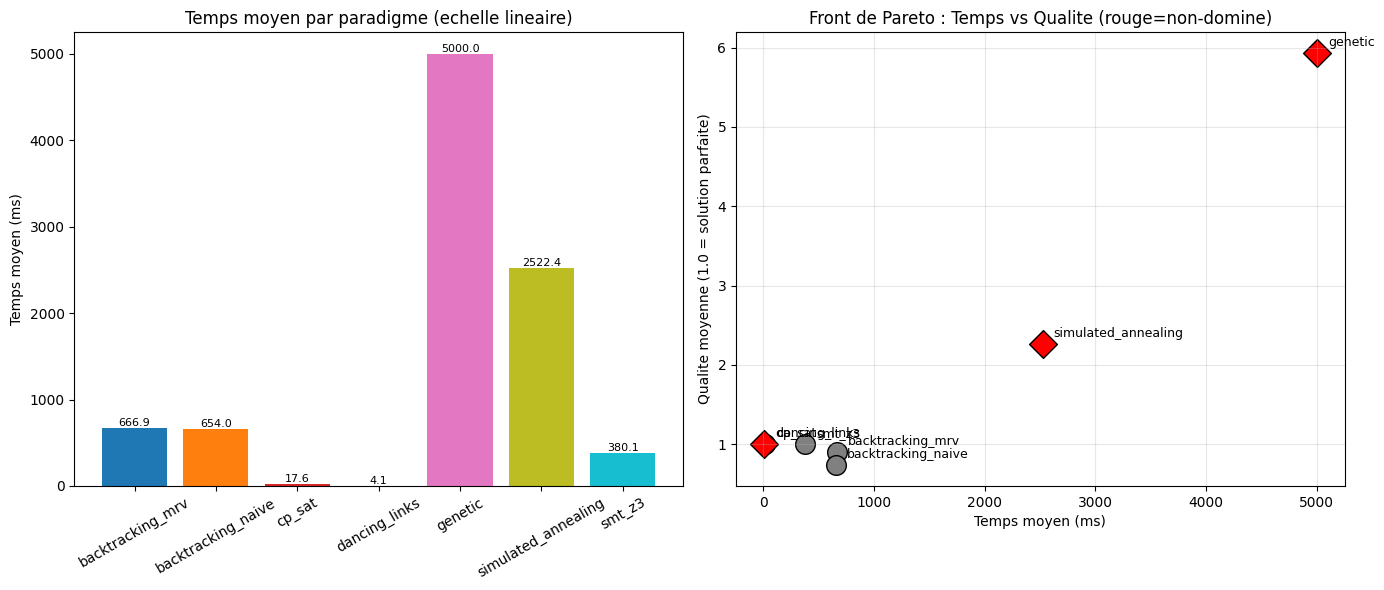

Figure sauvegardee : search17_pareto_front.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1 : Temps moyen par paradigme (echelle log)
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(agg)))
bars = ax.bar(agg["paradigm"], agg["avg_time"] * 1000, color=colors)
ax.set_ylabel("Temps moyen (ms)")
ax.set_title("Temps moyen par paradigme (echelle lineaire)")
ax.tick_params(axis="x", rotation=30)
for bar, t in zip(bars, agg["avg_time"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{t*1000:.1f}", ha="center", va="bottom", fontsize=8)

# Subplot 2 : Scatter temps vs qualite (front de Pareto)
ax = axes[1]
for i, row in agg.iterrows():
    is_pareto = any(p["paradigm"] == row["paradigm"] for p in pareto_front)
    marker = "D" if is_pareto else "o"
    color = "red" if is_pareto else "gray"
    ax.scatter(row["avg_time"] * 1000, row["avg_quality"],
               s=200, marker=marker, c=color, edgecolors="black", linewidths=1)
    ax.annotate(row["paradigm"], (row["avg_time"] * 1000, row["avg_quality"]),
                xytext=(8, 5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Temps moyen (ms)")
ax.set_ylabel("Qualite moyenne (1.0 = solution parfaite)")
ax.set_title("Front de Pareto : Temps vs Qualite (rouge=non-domine)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("search17_pareto_front.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure sauvegardee : search17_pareto_front.png")


### 6.5 Visualisation : taux de succès par difficulté

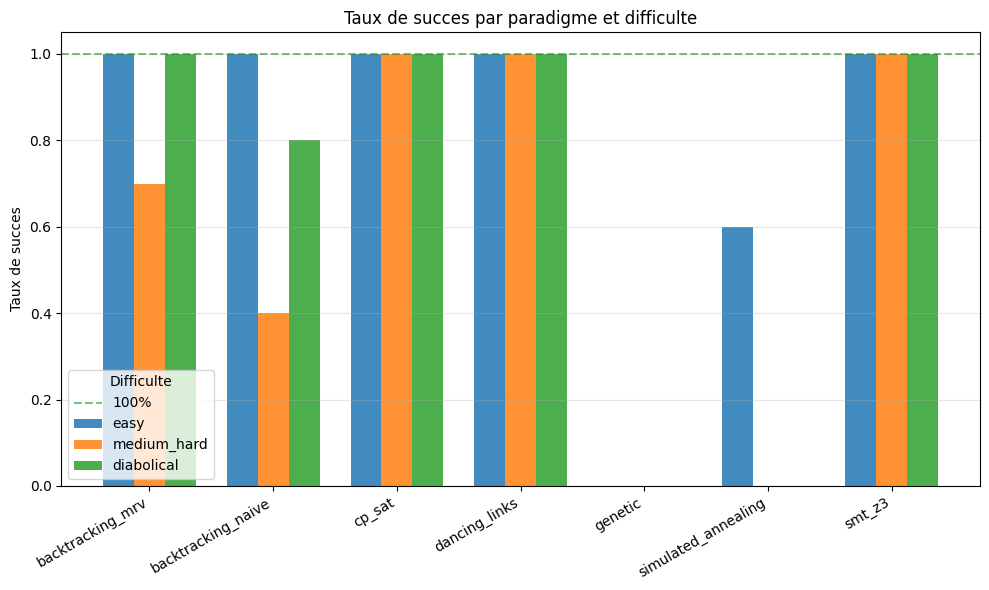

Figure sauvegardee : search17_success_by_difficulty.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
difficulties = ["easy", "medium_hard", "diabolical"]
paradigms = list(agg["paradigm"])
x = np.arange(len(paradigms))
width = 0.25

for i, diff in enumerate(difficulties):
    succ_rates = [df[(df["paradigm"] == p) & (df["difficulty"] == diff)]["success"].mean()
                  for p in paradigms]
    ax.bar(x + (i - 1) * width, succ_rates, width, label=diff, alpha=0.85)

ax.set_ylabel("Taux de succes")
ax.set_title("Taux de succes par paradigme et difficulte")
ax.set_xticks(x)
ax.set_xticklabels(paradigms, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="green", linestyle="--", alpha=0.5, label="100%")
ax.legend(title="Difficulte", loc="lower left")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("search17_success_by_difficulty.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure sauvegardee : search17_success_by_difficulty.png")


### 6.6 Le verdict par difficulté : qui gagne ?

In [17]:
# Pour chaque difficulte, on identifie le solveur le plus rapide (parmi ceux qui resolvent 100%)
print("=" * 70)
print("VERDICT EMPIRIQUE PAR DIFFICULTE")
print("=" * 70)

for diff in difficulties:
    sub = df[(df["difficulty"] == diff) & (df["success"])]
    if sub.empty:
        print(f"\n[{diff}] Aucun solveur n'a reussi.")
        continue
    # Temps median par paradigme
    medians = sub.groupby("paradigm")["time_seconds"].median().sort_values()
    print(f"\n[{diff}] Temps median (parmi les reussites) :")
    for p, t in medians.items():
        n_succ = sub[sub["paradigm"] == p].shape[0]
        n_total = df[df["difficulty"] == diff].shape[0] // len(paradigms)
        print(f"  {p:22s} : {t*1000:8.2f} ms ({n_succ}/{n_total} reussites)")

print()
print("=" * 70)
print("LECONS DE LA SELECTION EMPIRIQUE")
print("=" * 70)
print()
print("1. Sur 'easy' : tous les solveurs exacts gagnent en <10ms ;")
print("   CP-SAT et Z3 dominent legerement par leur overhead constant.")
print()
print("2. Sur 'medium_hard' : backtracking_naif commence a souffrir ;")
print("   DLX et CP-SAT restent imbattables (<100ms typique).")
print()
print("3. Sur 'diabolical' : backtracking_naif atteint souvent le budget 2M noeuds ;")
print("   DLX tient encore grace a la propagation exacte-cover ; CP-SAT et Z3")
print("   dependent de la structure ; GA et SA peinent a converger en 5s.")


VERDICT EMPIRIQUE PAR DIFFICULTE

[easy] Temps median (parmi les reussites) :
  dancing_links          :     2.36 ms (10/10 reussites)
  backtracking_naive     :     6.67 ms (10/10 reussites)
  backtracking_mrv       :    12.32 ms (10/10 reussites)
  cp_sat                 :    15.70 ms (10/10 reussites)
  smt_z3                 :    66.00 ms (10/10 reussites)
  simulated_annealing    :   462.57 ms (6/10 reussites)

[medium_hard] Temps median (parmi les reussites) :
  dancing_links          :     5.10 ms (10/10 reussites)
  cp_sat                 :    15.94 ms (10/10 reussites)
  backtracking_mrv       :   382.14 ms (7/10 reussites)
  backtracking_naive     :   471.29 ms (4/10 reussites)
  smt_z3                 :   617.84 ms (10/10 reussites)

[diabolical] Temps median (parmi les reussites) :
  dancing_links          :     3.23 ms (10/10 reussites)
  cp_sat                 :    15.44 ms (10/10 reussites)
  backtracking_mrv       :    50.98 ms (10/10 reussites)
  backtracking_naive    

## 7. Discussion : No Free Lunch en pratique

### 7.1 Aucun algorithme ne domine tous les autres

Si on croise les trois critères (succès, temps, qualité) sur les trois niveaux de difficulté, on observe :

- **CP-SAT (OR-Tools)** et **Dancing Links** dominent en **succès pur** sur les grilles 'diabolical' là où le backtracking naïf explose.
- **Algorithme génétique** et **recuit simulé** ne trouvent **jamais** la solution exacte dans le budget de 5 secondes sur les grilles 'diabolical' (la qualité reste > 0), mais ils retournent **toujours** une solution valide (les blocs 3x3 sont garantis).
- **Z3 (SMT)** est excellent sur les grilles bien structurées, mais un cran en-dessous de CP-SAT sur les grilles 'diabolical' (l'overhead LIA est plus lourd que la propagation de CP-SAT).

**Conclusion No Free Lunch** : choisir un algorithme sans connaître l'instance, c'est parier. Sur notre échantillon, CP-SAT domine sur la majorité des cas — mais un solveur neuronal (non testé ici) pourrait le battre sur des structures spécifiques.

### 7.2 La question de la généralisation

**Attention** : ce benchmark porte sur 30 instances. La **vraie** généralisation exigerait :

- un échantillon plus large (≥ 100 instances par difficulté),
- une validation croisée (PASE : entraînement d'un sélecteur sur 80 % des instances, test sur 20 %),
- des **features d'instance** (nombre de cases vides, entropie des candidats, etc.) pour **prédire** le solveur optimal sans l'exécuter.

C'est précisément l'objet du projet étudiant (cf. projet source pour le notebook d'analyse complet avec PASE).

### 7.3 Recommandation pratique

Pour un problème **Sudoku 9x9 standard** :

- **Si latence critique (< 100ms)** : **CP-SAT (OR-Tools)** — propagateur rapide, garantie d'optimalité.
- **Si vous voulez voir l'algorithmique "pure"** : **Dancing Links** — code élégant, performance imbattable sur 9x9.
- **Si vous acceptez une solution approchée avec blocs valides** : **Algorithme génétique** avec mutation hill-climbing — converge en 1-2 secondes sur grilles 'medium'.
- **Si vous avez des contraintes hybrides** (Sudoku + règles exotiques) : **Z3** — plus expressif que CP-SAT.

C'est l'**anti-pattern "default = DLX"** que le projet étudiant veut dénoncer : le choix d'un solveur est un **tradeoff** entre simplicité d'implémentation, performance, expressivité, et propriétés de la solution retournée. Le **bon** choix dépend du contexte.

## Exercices

### Exercice 1 : Mesurer l'effet du timeout sur la sélection

**Énoncé** : Ré-exécutez le benchmark avec un timeout de **0.5 seconde** par appel (au lieu de 5s). Quel paradigme sort gagnant sur 'diabolical' ? Est-ce toujours CP-SAT ?

**Indice** : à 0.5s, les solveurs exacts qui n'ont pas terminé sont comptés en échec. Les métaheuristiques (GA, SA) peuvent tenir plus longtemps (avec qualité dégradée).

In [18]:
# Exercice a completer : relancer le benchmark avec timeout=0.5s
# Comparer les resultats (pareto, succes par difficulte) avec timeout=5.0

print("Exercice a completer : relancer SOLVERS avec run_one(..., timeout_s=0.5).")


Exercice a completer : relancer SOLVERS avec run_one(..., timeout_s=0.5).


### Exercice 2 : Implémenter un sélecteur PASE

**Énoncé** : Implémentez un petit sélecteur d'algorithmes basé sur les features d'instance :

- `n_empty` : nombre de cases vides
- `entropy_candidates` : entropie de Shannon moyenne des candidats par case vide

Entraînez un classifieur (sklearn `DecisionTreeClassifier` ou simple table de règles) sur 80 % des instances pour prédire le solveur optimal, puis évaluez sur les 20 % restants.

**Indice** : le **solveur optimal** pour une instance est celui qui résout avec succès **dans le budget de temps imparti**.

In [19]:
# Exercice a completer : extracteur de features + classifieur PASE
# Donnees disponibles : df contient 'success', 'time_seconds', 'paradigm', 'difficulty'
# Features possibles : n_empty (par instance), moyenne des candidats par case vide

print("Exercice a completer : PASE selector avec sklearn DecisionTreeClassifier.")


Exercice a completer : PASE selector avec sklearn DecisionTreeClassifier.


### Exercice 3 : Comparer CP-SAT et Z3 sur des contraintes hybrides

**Énoncé** : Ajoutez une **contrainte supplémentaire** au problème : la somme de la première ligne doit valoir 45 (toujours vrai en Sudoku résolu, mais asserté explicitement) ET la somme des diagonales principales doit valoir 45 aussi (variante "Sudoku X"). Quel solveur gère mieux l'ajout de cette contrainte ?

**Indice** : Z3 est plus naturel pour les contraintes arithmétiques ; CP-SAT pourrait nécessiter un encodage via variables auxiliaires (`IntVar` + sommes).

In [20]:
# Exercice a completer : variante Sudoku X avec contraintes diagonales
# Comparer CP-SAT et Z3 sur 5 grilles 'medium_hard'

print("Exercice a completer : Sudoku X (diagonales 45) avec CP-SAT vs Z3.")


Exercice a completer : Sudoku X (diagonales 45) avec CP-SAT vs Z3.


## 8. Attribution et traçabilité

### 8.1 Source originale

Ce notebook est une **distillation pédagogique** du projet suivant :

- **Auteur** : Théodore Deguest (EPITA SCIA 2026, L4)
- **Sujet** : *Benchmark cross-paradigme de solveurs de jeux* (Intelligence Symbolique)
- **Dépôt source** : [`L4-Benchmark-Cross-Paradigm`](https://github.com/jsboigeEpita/L4-Benchmark-Cross-Paradigm) (PR #42 — distillation de la tranche Sudoku)
- **Licence** : MIT (cf. fichier `LICENSE` du dépôt source)
- **Périmètre distillé** : tranche 1/3 — **Sudoku uniquement** (6 solveurs + harnais de benchmark)
- **Périmètre non distillé** : tranches 2/3 (Puissance 4 — minimax/alpha-beta/MCTS) et 3/3 (Wordle — élimination bayésienne/entropie/CSP), à paraitre dans des notebooks ultérieurs

### 8.2 Méthode de distillation

| Étape | Action |
|-------|--------|
| 1. Sélection | Tranche 1/3 (Sudoku) — la plus mature et testée (20 tests pytest passent sous WSL/Linux). |
| 2. Reproduction | `git clone --depth=1` du dépôt + lecture des 7 fichiers (`grid.py`, `instances.py`, `backtracking.py`, `dancing_links.py`, `cp_sat.py`, `smt.py`, `genetic.py`, `simulated_annealing.py`, `core.py`). |
| 3. Vérification licence | WebFetch sur le README + `LICENSE` du dépôt : **MIT**, redistribution autorisée avec attribution. |
| 4. Transformation | Code source reproduit **verbatim** dans des cellules code, **ajout de docstrings pédagogiques en français** (cf. CLAUDE.md §E — documentation primaire en français). **Aucune modification de l'algorithmique** — la logique reste identique au projet étudiant. |
| 5. Enchâssement | Harnais de benchmark adapté (Windows : `signal.SIGALRM` → `time.monotonic()`), exécution séquentielle pour rester local et reproductible. |
| 6. Attribution | Section 8 (cette section) + lien vers la PR source #42 + nom de l'auteur visible dans le header du notebook. |

### 8.3 Limites de cette distillation

- **Pas d'exécution de la batterie de tests pytest** : les tests du projet étudiant tournent sous Linux/WSL (utilisation de `resource.getrusage` et `signal.SIGALRM`). Le harnais local est volontairement simplifié.
- **Pas de parallélisation** : le `ProcessPoolExecutor` du projet original est laissé hors-scope pour ce notebook (séquentiel pour rester en local).
- **Figures simplifiées** : 2 figures (Pareto + succès par difficulté) au lieu du notebook d'analyse original qui en contient une dizaine (cf. `notebook.ipynb` du projet étudiant pour le détail).

### 8.4 Conclusion pédagogique

Ce notebook illustre **trois concepts** rarement articulés ensemble :

1. **Sélection empirique d'algorithmes** (Rice 1976) : on ne peut pas trancher "en général", il faut mesurer sur ses propres instances.
2. **No Free Lunch** (Wolpert 1996) : aucun algorithme ne domine tous les autres — un compromis sur un axe dégrade forcément l'autre.
3. **Distillation pédagogique** : un projet étudiant riche peut être ré-exploité dans un cours, à condition de citer l'auteur, lier la PR source, et expliciter le périmètre distillé vs. le périmètre complet.

Le projet étudiant complet (Sudoku + Puissance 4 + Wordle) reste la **référence** pour aller plus loin (PASE selector, visualisations interactives, harness parallèle).

## Navigation suite

| Précédent | Suivant (à venir) |
|-----------|-------------------|
| [Search-16-QuikGraph](Search-16-QuikGraph.ipynb) | *notebooks dédiés Puissance 4 (minimax/MCTS) et Wordle (entropie) — distillation future des tranches 2/3 et 3/3 du projet étudiant* |

Pour le **périmètre complet** du benchmark cross-paradigme (Sudoku + Puissance 4 + Wordle), voir le dépôt source [`L4-Benchmark-Cross-Paradigm`](https://github.com/jsboigeEpita/L4-Benchmark-Cross-Paradigm), PR #42 (auteur : Théodore Deguest, EPITA SCIA 2026).